In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir(r"C:\Users\Rinku\Desktop\mutual-fund-analysis")
print(os.getcwd())

C:\Users\Rinku\Desktop\mutual-fund-analysis


In [3]:
nav = pd.read_csv(
    "data/raw/02_nav_history.csv",
    parse_dates=["date"]
)

transactions = pd.read_csv(
    "data/raw/08_investor_transactions.csv",
    parse_dates=["transaction_date"]
)

performance = pd.read_csv(
    "data/raw/07_scheme_performance.csv"
)

portfolio = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [4]:
print("NAV Shape :", nav.shape)
print("Transactions Shape :", transactions.shape)
print("Performance Shape :", performance.shape)
print("Portfolio Shape :", portfolio.shape)

NAV Shape : (46000, 3)
Transactions Shape : (32778, 13)
Performance Shape : (40, 19)
Portfolio Shape : (322, 8)


In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [6]:
var_list = []

for fund in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"] == fund
        ]["daily_return"]
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar = (
        returns[
            returns <= var_95
        ]
        .mean()
    )

    var_list.append([
        fund,
        var_95,
        cvar
    ])

var_df = pd.DataFrame(
    var_list,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR"
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_df.to_csv(
    "reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [8]:
key_funds = [
    119551,
    119552,
    119598,
    119599,
    120505
]

key_funds

[119551, 119552, 119598, 119599, 120505]

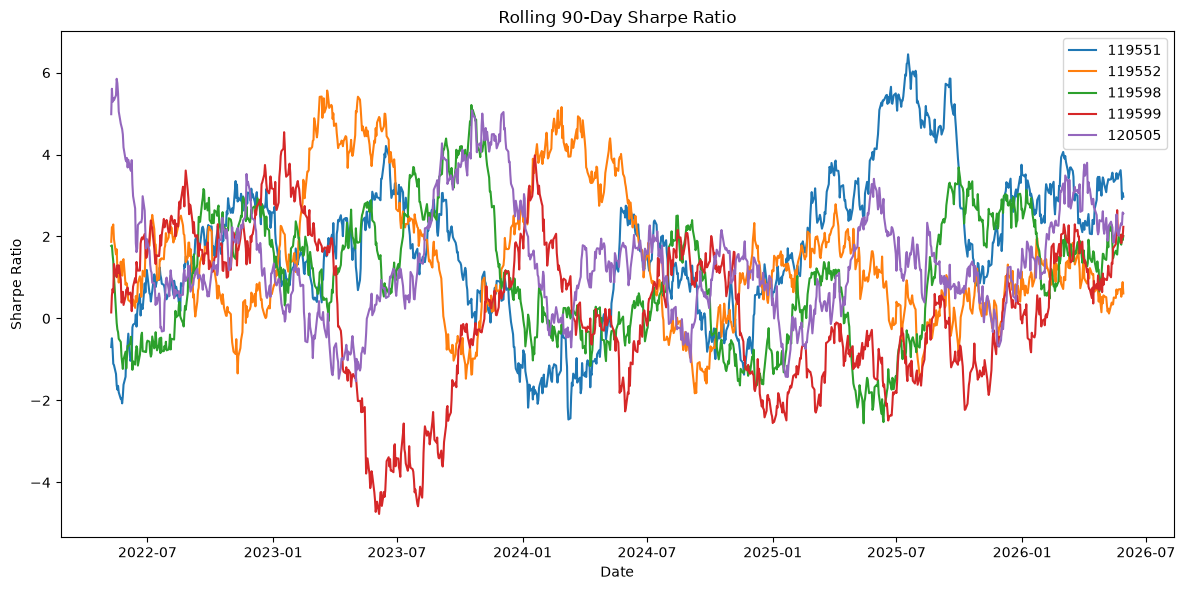

In [9]:
plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()

plt.show()

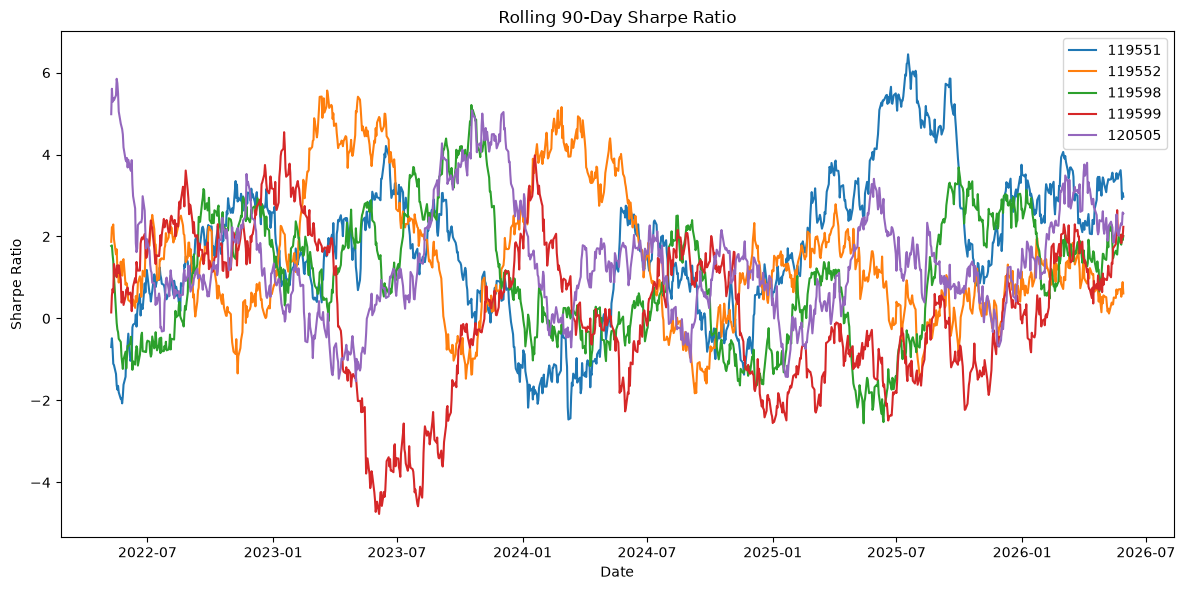

rolling_sharpe_chart.png saved successfully


In [10]:
plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()

plt.savefig(
    "reports/rolling_sharpe_chart.png"
)

plt.show()

print("rolling_sharpe_chart.png saved successfully")

In [11]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [12]:
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [13]:
transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [14]:
cohort_analysis = (
    transactions.groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr", "mean"),
        total_investment=("amount_inr", "sum"),
        total_investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,avg_investment,total_investment,total_investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [15]:
top_fund = (
    transactions.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [16]:
cohort_analysis = cohort_analysis.merge(
    top_fund[
        ["cohort_year", "amfi_code"]
    ],
    on="cohort_year",
    how="left"
)

cohort_analysis

,cohort_year,avg_investment,total_investment,total_investors,amfi_code
0,2024,107422.541832,3491125187,4803,148568
1,2025,109158.577061,30455243,197,119599


In [17]:
cohort_analysis.to_csv(
    "reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully")

cohort_analysis.csv saved successfully


In [18]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

print(sip.shape)
sip.head()

(19716, 14)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [19]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [20]:
sip_analysis = (
    sip.groupby("investor_id")
       .agg(
           avg_gap=("gap_days", "mean"),
           sip_count=("gap_days", "count")
       )
       .reset_index()
)

sip_analysis = sip_analysis[
    sip_analysis["sip_count"] >= 6
]

sip_analysis.head()

,investor_id,avg_gap,sip_count
10,INV000011,40.166667,6
11,INV000012,57.000000,7
12,INV000013,55.333333,6
13,INV000014,75.333333,6
22,INV000023,58.571429,7


In [21]:
sip_analysis["status"] = np.where(
    sip_analysis["avg_gap"] > 35,
    "At Risk",
    "Active"
)

sip_analysis.head()

,investor_id,avg_gap,sip_count,status
10,INV000011,40.166667,6,At Risk
11,INV000012,57.000000,7,At Risk
12,INV000013,55.333333,6,At Risk
13,INV000014,75.333333,6,At Risk
22,INV000023,58.571429,7,At Risk


In [22]:
sip_analysis.to_csv(
    "reports/sip_continuity.csv",
    index=False
)

print("sip_continuity.csv saved successfully")

sip_continuity.csv saved successfully


In [23]:
performance["risk_grade"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [24]:
def recommend_funds(risk):

    temp = performance[
        performance["risk_grade"]
        .str.contains(
            risk,
            case=False,
            na=False
        )
    ]

    temp = temp.sort_values(
        "sharpe_ratio",
        ascending=False
    )

    return temp[
        [
            "scheme_name",
            "fund_house",
            "risk_grade",
            "sharpe_ratio"
        ]
    ].head(3)

In [25]:
recommend_funds("Moderate")

,scheme_name,fund_house,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03


In [26]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [28]:
portfolio["weight_sq"] = (
    portfolio["weight_pct"] ** 2
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_sq
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,191.8225
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,125.2161
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,98.0100
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,22.6576
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,105.0625


In [29]:
hhi = (
    portfolio.groupby("amfi_code")
             ["weight_sq"]
             .sum()
             .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


In [30]:
hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,2064.4767
3,101207,2007.0043
18,119599,1747.5096
4,102885,1747.0902
7,118632,1682.9820
29,148568,1679.2973
21,120505,1575.7036
22,120506,1537.9360
27,125498,1524.1398
23,120841,1496.8035


In [31]:
hhi.to_csv(
    "reports/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv saved successfully")

sector_hhi.csv saved successfully
